# Cis4930 Project 1
## Liam Sharkey

In [67]:
#setup
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import ast

#there's a lot of stuff in there i dont want
useful_cols = ['appid', 'name', 'release_date', 'price', 'dlc_count',
                'windows', 'mac', 'linux', 'metacritic_score',
               'achievements','recommendations','supported_languages',
               'full_audio_languages','developers','publishers','categories',
               'genres','score_rank','positive','negative','average_playtime_forever',
               'average_playtime_2weeks','median_playtime_forever',
               'median_playtime_2weeks','discount','peak_ccu','tags',
               'pct_pos_total','num_reviews_total','pct_pos_recent',
               'num_reviews_recent']

#had to specify python engine because c was having problems
df = pd.read_csv('data/raw/games_march2025_full.csv', 
        on_bad_lines='skip', engine='python', usecols=useful_cols)

#fill in missing data with average where available, and sentinel where not
df = df.fillna(df.mean(numeric_only=True))
string_columns = df.select_dtypes(include=['str']).columns
df[string_columns] = df[string_columns].fillna('MISSING')
pd.isnull(df).sum().sum()

#convert bools to ints
df['windows'] = df['windows'].astype(int)
df['mac'] = df['mac'].astype(int)
df['linux'] = df['linux'].astype(int)

#convert to proper lists
df["supported_languages"] = df["supported_languages"].apply(ast.literal_eval)
df["full_audio_languages"] = df['full_audio_languages'].apply(ast.literal_eval)
df['genres'] = df['genres'].apply(ast.literal_eval)

#convert release date to datetime obj
df['release_date'] = pd.to_datetime(df['release_date'])

#df.loc[df['pct_pos_total'].idxmax()]  #for ref

In [68]:
df.describe()

,appid,release_date,price,dlc_count,windows,mac,linux,metacritic_score,achievements,recommendations,...,average_playtime_forever,average_playtime_2weeks,median_playtime_forever,median_playtime_2weeks,discount,peak_ccu,pct_pos_total,num_reviews_total,pct_pos_recent,num_reviews_recent
count,9.040000e+04,90400,90400.000000,90400.000000,90400.000000,90400.000000,90400.000000,90400.000000,90400.000000,9.040000e+04,...,9.040000e+04,90400.000000,9.040000e+04,90400.000000,90400.000000,9.040000e+04,90400.000000,9.040000e+04,90400.000000,90400.000000
mean,1.698749e+06,2021-05-15 09:48:41.734513,6.953921,0.584480,0.999668,0.186947,0.135277,2.900819,20.124591,1.073639e+03,...,1.140647e+02,4.996659,1.138092e+02,5.270376,4.403197,9.752251e+01,46.925907,1.520945e+03,5.646338,17.779403
min,2.000000e+01,1997-06-30 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,...,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0.000000e+00,-1.000000,-1.000000e+00,-1.000000,-1.000000
25%,8.751975e+05,2019-01-28 00:00:00,0.990000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,...,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0.000000e+00,-1.000000,-1.000000e+00,-1.000000,-1.000000
50%,1.583430e+06,2022-02-09 00:00:00,3.990000,0.000000,1.000000,0.000000,0.000000,0.000000,3.000000,0.000000e+00,...,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0.000000e+00,62.000000,1.700000e+01,-1.000000,-1.000000
75%,2.485098e+06,2024-01-19 00:00:00,9.990000,0.000000,1.000000,0.000000,0.000000,0.000000,20.000000,0.000000e+00,...,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0.000000e+00,85.000000,9.000000e+01,-1.000000,-1.000000
max,3.570420e+06,2025-03-10 00:00:00,999.980000,3427.000000,1.000000,1.000000,1.000000,97.000000,9821.000000,4.401572e+06,...,1.462997e+06,18568.000000,1.462997e+06,18568.000000,100.000000,1.212356e+06,100.000000,8.632939e+06,100.000000,96473.000000
std,9.291075e+05,NaN,13.167653,15.274738,0.018214,0.389871,0.342021,14.443214,163.699897,2.330537e+04,...,6.785285e+03,180.329695,8.768545e+03,188.819105,16.282217,5.692771e+03,40.515959,3.636148e+04,22.972753,470.504368


## How does accessibility effect a game

Support score represents the number of different types of people
who would be able to confortably and conveniently play the game

In [69]:
df["accessibility_score"] = (df['windows'] + df['mac'] + df['linux'] + 
    df['supported_languages'].apply(len) + df['full_audio_languages'].apply(len))

<function matplotlib.pyplot.show(close=None, block=None)>

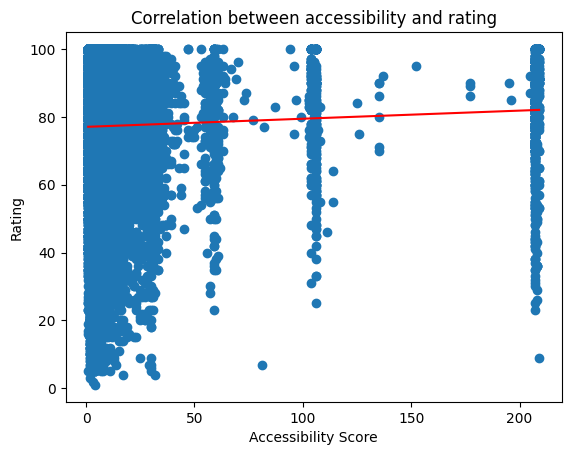

In [70]:
filtered_df = df[df['pct_pos_total'] > 0] #a user score of 0 implies no reviews
x = filtered_df['accessibility_score']
y = filtered_df['pct_pos_total']
plt.scatter(x, y)
plt.plot(np.unique(x), np.poly1d(np.polyfit(x, y, 1))(np.unique(x)), color='red')
plt.xlabel("Accessibility Score")
plt.ylabel("Rating")
plt.title("Correlation between accessibility and rating")
plt.savefig("./figures/accessibility_scatter.png")
plt.show

## What genre is most popular

,negative,pct_pos_total,positive
genres,,,
Accounting,8.0,93.0,132.0
Action,12.0,80.0,40.0
Adventure,11.0,81.0,40.0
Animation & Modeling,5.5,89.0,23.5
Audio Production,14.5,88.5,163.0
Casual,6.0,82.0,26.0
Design & Illustration,1.5,95.5,43.0
Early Access,10.0,76.0,28.0
Education,6.0,70.0,20.0


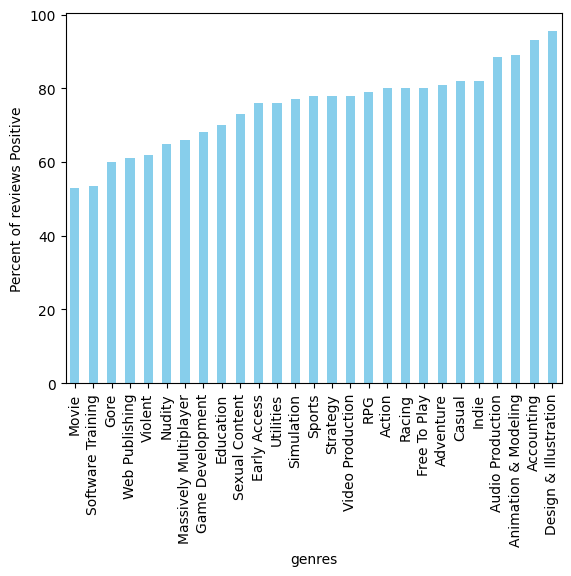

In [71]:
df_genres = df.explode('genres')
df_genres = df_genres[df_genres['pct_pos_total'] >= 0] #-1 doesn't mean anyhting
genre_grouped = df_genres.groupby('genres')['pct_pos_total'].median().sort_values()
genre_grouped.plot(kind='bar', color='skyblue')
plt.ylabel("Percent of reviews Positive")
plt.savefig("./figures/genre_popularity_bar.png")

pt = df_genres.pivot_table(values=['pct_pos_total', 'negative', 'positive'],
                    index='genres', aggfunc='median')
pt

## Price over time

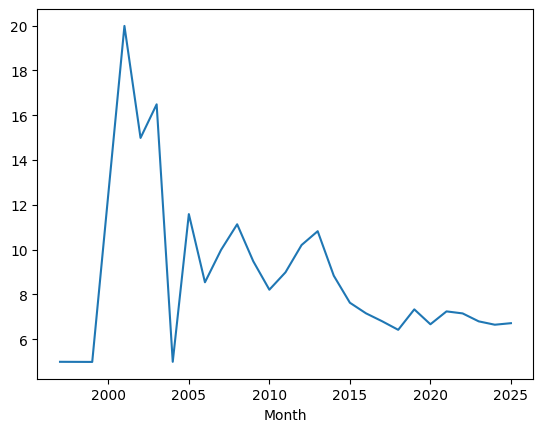

In [86]:
price_over_time = df.groupby(df['release_date'].dt.year)['price'].mean()
price_over_time.plot()
plt.xlabel("Month")
plt.savefig("./figures/price_over_time.png")

## Price and playtime

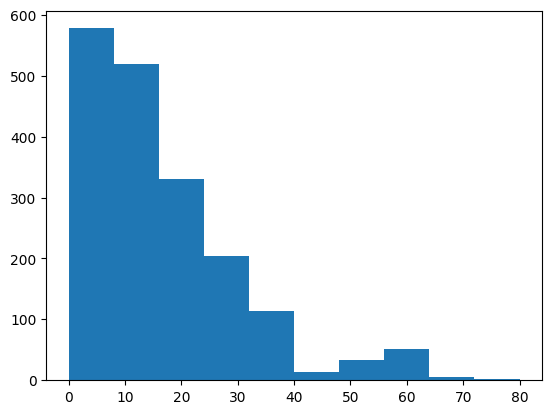

In [73]:
df_filterd = df[df['average_playtime_forever'] > 0]
price_playtime = df_filterd.groupby('average_playtime_forever')['price'].median()
plt.hist(price_playtime)
plt.savefig("./figures/price_playtime_hist.png")

## Correlation between all values

<Axes: >

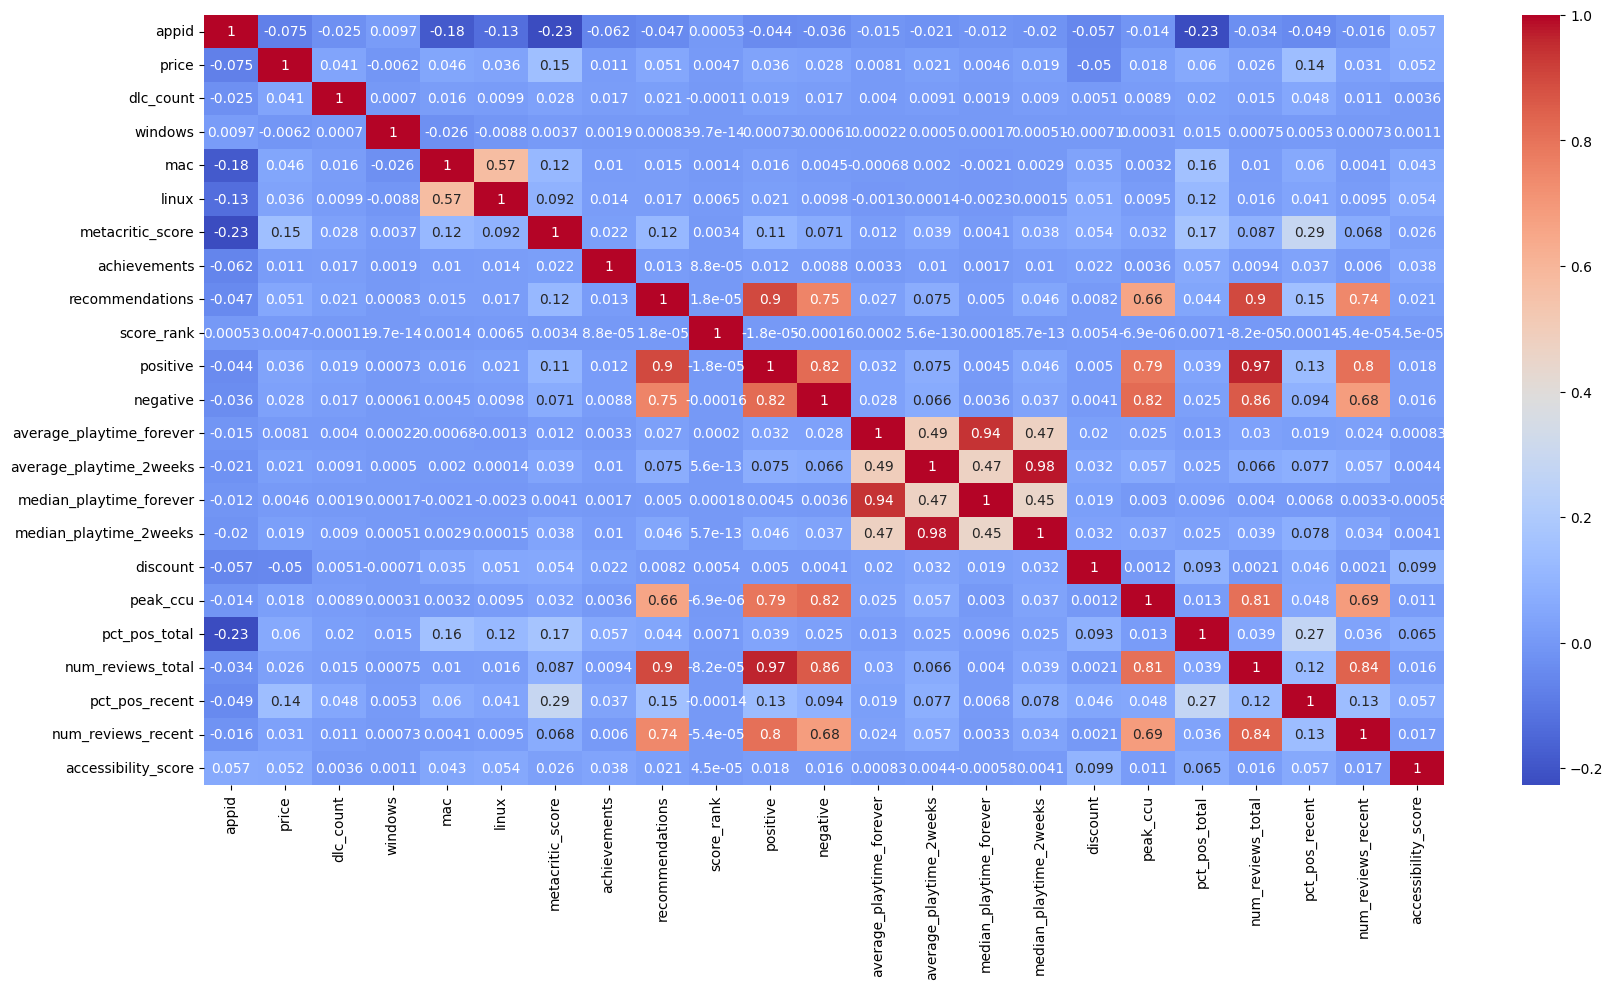

In [ ]:
df_numerics = df.select_dtypes(include='number')
correlation = df_numerics.corr()
plt.figure(figsize=(20,10))
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.savefig("./figures/correlation.png")


# Summary
-There is a slight correlation between accessibility and ratings.
-Design and illustration games are most popular, though they're likely apps more than games.
-Game price has come down and stabilized in recent years, likely due to newer free to
    play models
-Surprisingly, cheaper games tend to have more playtime on them, I think this is because
    a lot of indie games have very dedicated playerbases, and AAA free to play games
    can be very addictive. (CounterStrike, Dota, Leage of Legends, Fortnite ...)
-Interestingly, older games (lower appid) have higher reviews, and are more likely to 
    support mac and linux. Just a little interesting.